# Dual Solver + Oracle Pipeline: Comprehensive Analysis

This notebook analyzes the results from the dual solver (CoT + PoT with self-consistency) oracle pipeline evaluation on GSM8K test set.

**Pipeline Overview:**
- Student Model: Llama 3.2 3B (makes 2 calls per problem: CoT + PoT with 5 self-consistency samples each)
- Oracle Model: Gemma 3 27B (called only when methods disagree or both fail)
- Strategy: Agreement-based with intelligent oracle fallback

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load JSON file
results_file = Path('results_enhanced_oracle_oracle_cot.json')

if results_file.exists():
    with open(results_file, 'r') as f:
        data = json.load(f)
    
    print(f"✓ Loaded results from {results_file}")
    print(f"  Total problems: {len(data['results'])}")
    print(f"  Config: {data['config']}")
else:
    print(f"❌ File not found: {results_file}")
    print("Please specify the correct path to your JSON results file.")

✓ Loaded results from results_enhanced_oracle_oracle_cot.json
  Total problems: 1319
  Config: {'student_model': 'meta-llama/llama-3.2-3b-instruct', 'oracle_model': 'google/gemma-3-27b-it', 'num_samples': 5, 'oracle_samples': 5, 'strategy': 'Dual Solver (CoT + PoT) with Enhanced Oracle (8-shot CoT + SC + Calculator)'}


## Section 1: Parse and Explore Data

In [2]:
# Convert results to DataFrame
df = pd.DataFrame(data['results'])

print(f"DataFrame shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df[['question', 'cot_answer', 'pot_answer', 'final_answer', 'method', 'oracle_called', 'correct']].head())

DataFrame shape: (1319, 9)

Column names:
['problem_id', 'question', 'ground_truth', 'cot_answer', 'pot_answer', 'final_answer', 'method', 'oracle_called', 'correct']

First few rows:
                                            question  cot_answer  pot_answer  \
0  A robe takes 2 bolts of blue fiber and half th...         3.0         3.0   
1  James decides to run 3 sprints 3 times a week....       540.0       540.0   
2  Toulouse has twice as many sheep as Charleston...       260.0       260.0   
3  Every day, Wendi feeds each of her chickens th...        20.0        20.0   
4  Janet’s ducks lay 16 eggs per day. She eats th...        18.0        18.0   

   final_answer     method  oracle_called  correct  
0           3.0  agreement          False     True  
1         540.0  agreement          False     True  
2         260.0  agreement          False     True  
3          20.0  agreement          False     True  
4          18.0  agreement          False     True  


## Section 2: Oracle Call Statistics

In [3]:
# Calculate Oracle statistics
total_problems = len(df)
oracle_called_count = df['oracle_called'].sum()
oracle_called_percentage = 100 * oracle_called_count / total_problems

# Oracle called AND correct
oracle_called_and_correct = ((df['oracle_called']) & (df['correct'])).sum()
oracle_called_correct_percentage = 100 * oracle_called_and_correct / oracle_called_count if oracle_called_count > 0 else 0

# Oracle called AND incorrect
oracle_called_and_incorrect = ((df['oracle_called']) & (~df['correct'])).sum()
oracle_called_incorrect_percentage = 100 * oracle_called_and_incorrect / oracle_called_count if oracle_called_count > 0 else 0

# Cases where oracle was called, but one method (CoT or PoT) was already correct
oracle_called_method_correct = 0
for idx, row in df[df['oracle_called']].iterrows():
    if (row['cot_answer'] is not None and row['cot_answer'] == row['ground_truth']) or \
       (row['pot_answer'] is not None and row['pot_answer'] == row['ground_truth']):
        oracle_called_method_correct += 1

# Cases where oracle was called, and both methods were wrong but oracle fixed it
oracle_fixed_both_wrong = 0
for idx, row in df[df['oracle_called']].iterrows():
    cot_correct = (row['cot_answer'] is not None and row['cot_answer'] == row['ground_truth'])
    pot_correct = (row['pot_answer'] is not None and row['pot_answer'] == row['ground_truth'])
    if not (cot_correct or pot_correct) and row['correct']:
        oracle_fixed_both_wrong += 1

print("="*60)
print("ORACLE CALL STATISTICS")
print("="*60)
print(f"Total problems:                      {total_problems}")
print(f"Oracle called:                       {oracle_called_count} ({oracle_called_percentage:.2f}%)")
print(f"Oracle called AND correct:           {oracle_called_and_correct} ({oracle_called_correct_percentage:.2f}%)")
print(f"Oracle called AND incorrect:         {oracle_called_and_incorrect} ({oracle_called_incorrect_percentage:.2f}%)")
print(f"\nOracle called, but method was correct: {oracle_called_method_correct}")
print(f"Oracle fixed both methods wrong:      {oracle_fixed_both_wrong}")
print("="*60)

ORACLE CALL STATISTICS
Total problems:                      1319
Oracle called:                       403 (30.55%)
Oracle called AND correct:           351 (87.10%)
Oracle called AND incorrect:         52 (12.90%)

Oracle called, but method was correct: 270
Oracle fixed both methods wrong:      96


## Section 3: Correctness Metrics by Method

In [4]:
# Analyze by method
methods_stats = {}

for method in df['method'].unique():
    method_df = df[df['method'] == method]
    method_count = len(method_df)
    method_correct = method_df['correct'].sum()
    method_accuracy = 100 * method_correct / method_count if method_count > 0 else 0
    method_oracle = method_df['oracle_called'].sum()
    
    methods_stats[method] = {
        'count': method_count,
        'correct': method_correct,
        'accuracy': method_accuracy,
        'oracle_called': method_oracle
    }

print("\n" + "="*60)
print("CORRECTNESS BY METHOD")
print("="*60)
for method, stats in methods_stats.items():
    print(f"\n{method.upper()}")
    print(f"  Count:       {stats['count']}")
    print(f"  Correct:     {stats['correct']}")
    print(f"  Accuracy:    {stats['accuracy']:.2f}%")
    print(f"  Oracle Used: {stats['oracle_called']}")

# Overall accuracy
total_correct = df['correct'].sum()
overall_accuracy = 100 * total_correct / total_problems

print("\n" + "="*60)
print(f"OVERALL ACCURACY: {total_correct}/{total_problems} = {overall_accuracy:.2f}%")
print("="*60)


CORRECTNESS BY METHOD

AGREEMENT
  Count:       915
  Correct:     868
  Accuracy:    94.86%
  Oracle Used: 0

ORACLE_TIEBREAKER
  Count:       403
  Correct:     351
  Accuracy:    87.10%
  Oracle Used: 403

COT_ONLY
  Count:       1
  Correct:     0
  Accuracy:    0.00%
  Oracle Used: 0

OVERALL ACCURACY: 1219/1319 = 92.42%


## Section 4: Summary Statistics Table

In [5]:
# Create comprehensive summary table
summary_data = {
    'Metric': [
        'Total Problems',
        'Overall Accuracy',
        'Oracle Call Rate',
        'Oracle Success Rate',
        'Agreement Rate',
        'Average Calls per Problem',
        'Oracle Fixed Both Methods Wrong',
        'Oracle Called but Method Already Correct'
    ],
    'Value': [
        total_problems,
        f"{overall_accuracy:.2f}%",
        f"{oracle_called_percentage:.2f}%",
        f"{oracle_called_correct_percentage:.2f}%",
        f"{100 * len(df[df['method'] == 'agreement']) / total_problems:.2f}%",
        f"{1 + (oracle_called_count / total_problems):.2f}",
        oracle_fixed_both_wrong,
        oracle_called_method_correct
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)


COMPREHENSIVE SUMMARY STATISTICS
                                  Metric  Value
                          Total Problems   1319
                        Overall Accuracy 92.42%
                        Oracle Call Rate 30.55%
                     Oracle Success Rate 87.10%
                          Agreement Rate 69.37%
               Average Calls per Problem   1.31
         Oracle Fixed Both Methods Wrong     96
Oracle Called but Method Already Correct    270


## Section 5: Oracle Usage Visualizations

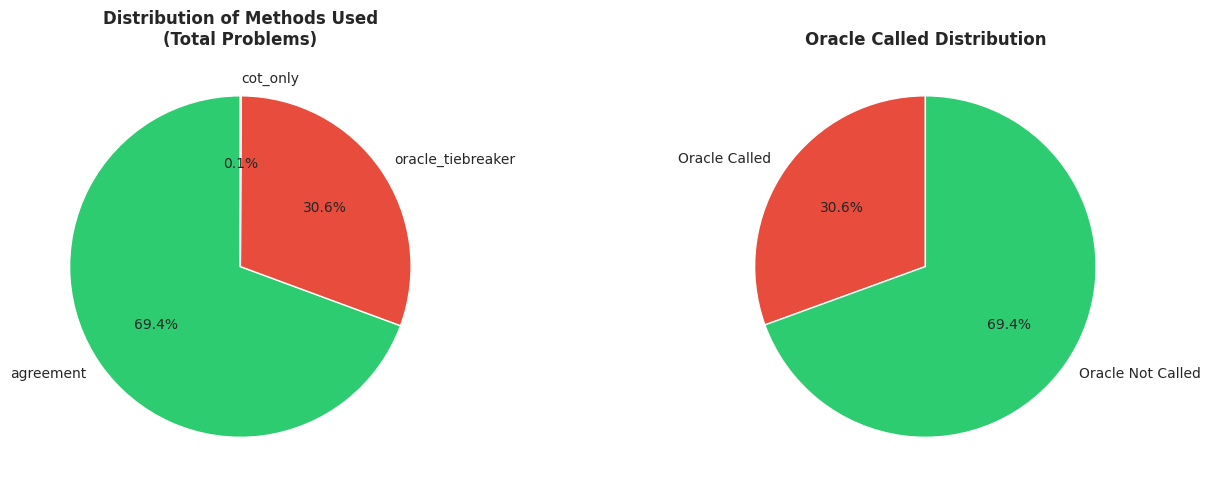

✓ Method distribution visualizations created


In [6]:
# Figure 1: Distribution of Methods Used
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: Method distribution
method_counts = df['method'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
axes[0].pie(method_counts.values, labels=method_counts.index, autopct='%1.1f%%', 
           colors=colors[:len(method_counts)], startangle=90)
axes[0].set_title('Distribution of Methods Used\n(Total Problems)', fontsize=12, fontweight='bold')

# Pie chart: Oracle called vs Not called
oracle_dist = pd.Series({
    'Oracle Called': oracle_called_count,
    'Oracle Not Called': total_problems - oracle_called_count
})
axes[1].pie(oracle_dist.values, labels=oracle_dist.index, autopct='%1.1f%%',
           colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Oracle Called Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Method distribution visualizations created")

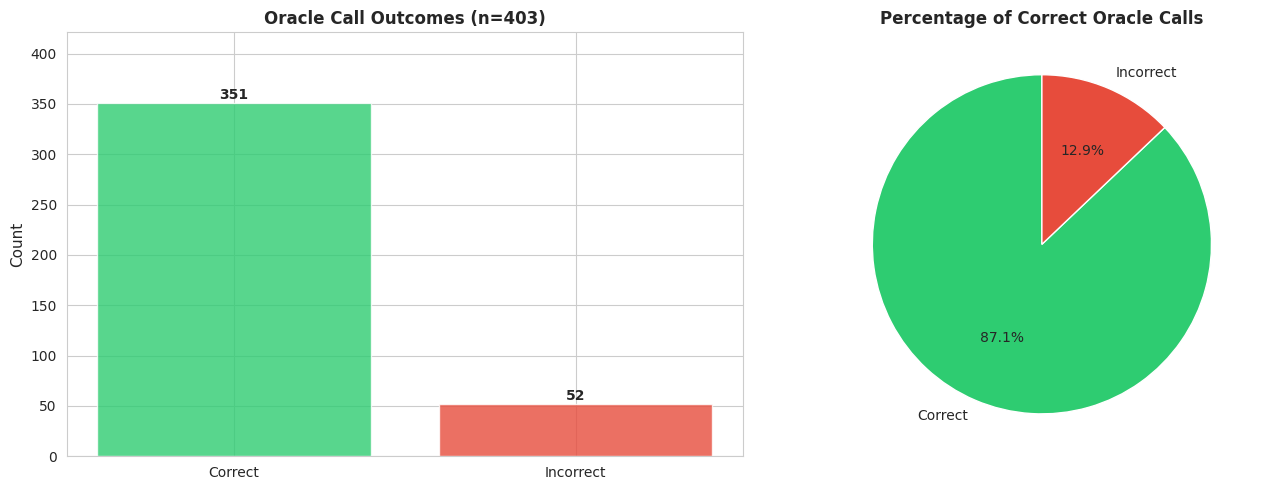

✓ Oracle outcomes visualizations created


In [7]:
# Figure 2: Oracle Call Outcomes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Oracle call outcomes
oracle_outcomes = pd.Series({
    'Correct': oracle_called_and_correct,
    'Incorrect': oracle_called_and_incorrect
})
axes[0].bar(oracle_outcomes.index, oracle_outcomes.values, color=['#2ecc71', '#e74c3c'], alpha=0.8)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title(f'Oracle Call Outcomes (n={oracle_called_count})', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(oracle_outcomes.values) * 1.2)
for i, v in enumerate(oracle_outcomes.values):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# Pie chart: Oracle outcomes
axes[1].pie(oracle_outcomes.values, labels=oracle_outcomes.index, autopct='%1.1f%%',
           colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Percentage of Correct Oracle Calls', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Oracle outcomes visualizations created")

## Section 6: Correctness Analysis by Method

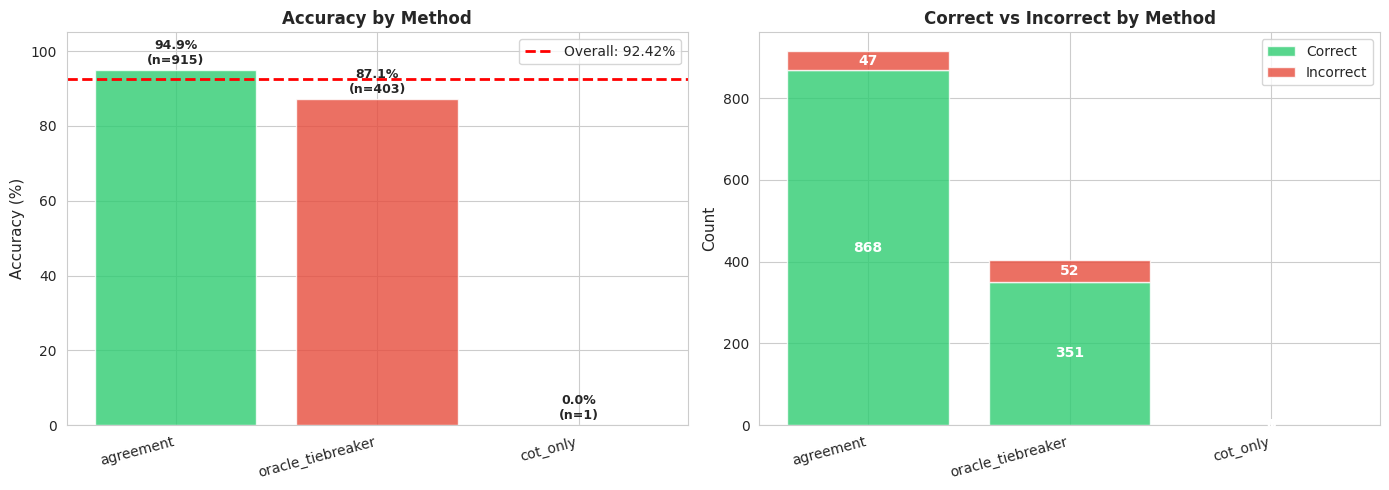

✓ Accuracy by method visualizations created


In [8]:
# Figure 3: Accuracy by Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for bar chart
methods = list(methods_stats.keys())
counts = [methods_stats[m]['count'] for m in methods]
accuracies = [methods_stats[m]['accuracy'] for m in methods]
correct_counts = [methods_stats[m]['correct'] for m in methods]

# Bar chart: Accuracy by method
x_pos = np.arange(len(methods))
colors_methods = ['#2ecc71', '#e74c3c', '#3498db'][:len(methods)]
bars = axes[0].bar(x_pos, accuracies, color=colors_methods, alpha=0.8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(methods, rotation=15, ha='right')
axes[0].set_ylabel('Accuracy (%)', fontsize=11)
axes[0].set_title('Accuracy by Method', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 105)
axes[0].axhline(y=overall_accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_accuracy:.2f}%')
axes[0].legend()

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{acc:.1f}%\n(n={counts[i]})', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Stacked bar chart: Correct vs Incorrect by method
incorrect_counts = [counts[i] - correct_counts[i] for i in range(len(methods))]
x_pos = np.arange(len(methods))
axes[1].bar(x_pos, correct_counts, label='Correct', color='#2ecc71', alpha=0.8)
axes[1].bar(x_pos, incorrect_counts, bottom=correct_counts, label='Incorrect', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(methods, rotation=15, ha='right')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Correct vs Incorrect by Method', fontsize=12, fontweight='bold')
axes[1].legend()

# Add count labels
for i, (correct, incorrect) in enumerate(zip(correct_counts, incorrect_counts)):
    axes[1].text(i, correct/2, str(correct), ha='center', va='center', fontweight='bold', color='white')
    axes[1].text(i, correct + incorrect/2, str(incorrect), ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("✓ Accuracy by method visualizations created")

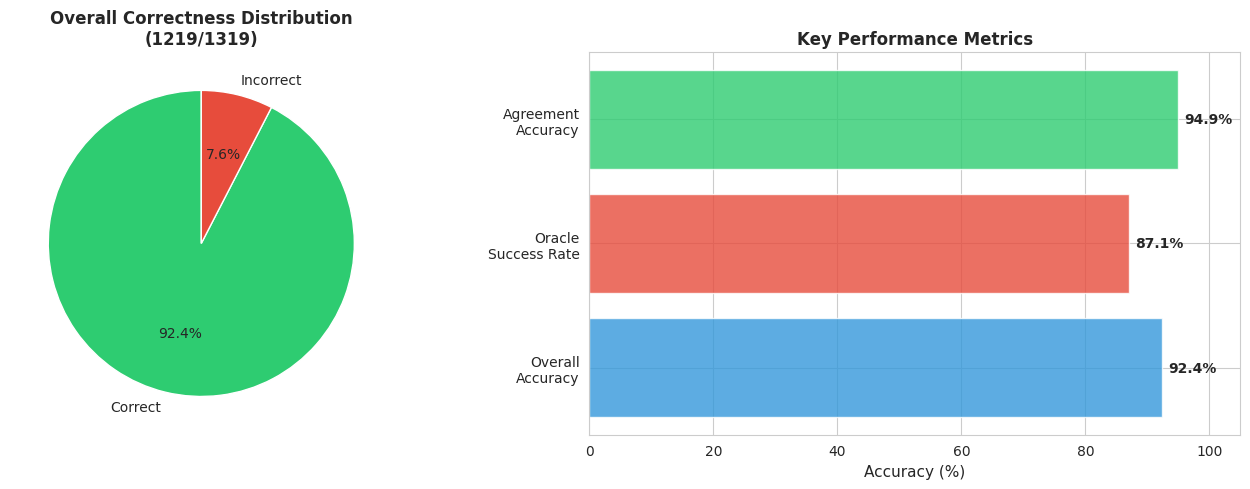

✓ Overall correctness visualizations created


In [9]:
# Figure 4: Overall Correctness Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart: Overall correctness
overall_correct = df['correct'].sum()
overall_incorrect = total_problems - overall_correct
correct_dist = pd.Series({
    'Correct': overall_correct,
    'Incorrect': overall_incorrect
})
colors_correct = ['#2ecc71', '#e74c3c']
axes[0].pie(correct_dist.values, labels=correct_dist.index, autopct='%1.1f%%',
           colors=colors_correct, startangle=90)
axes[0].set_title(f'Overall Correctness Distribution\n({overall_correct}/{total_problems})', 
                 fontsize=12, fontweight='bold')

# Horizontal bar chart: Key metrics
metrics_names = ['Overall\nAccuracy', 'Oracle\nSuccess Rate', 'Agreement\nAccuracy']
metrics_values = [
    overall_accuracy,
    oracle_called_correct_percentage if oracle_called_count > 0 else 0,
    100 * len(df[(df['method'] == 'agreement') & (df['correct'])]) / len(df[df['method'] == 'agreement']) 
    if len(df[df['method'] == 'agreement']) > 0 else 0
]

bars = axes[1].barh(metrics_names, metrics_values, color=['#3498db', '#e74c3c', '#2ecc71'], alpha=0.8)
axes[1].set_xlabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Key Performance Metrics', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, 105)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, metrics_values)):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
                ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Overall correctness visualizations created")

## Section 7: Detailed Analysis - Special Cases

In [10]:
# Detailed analysis of special cases
print("\n" + "="*80)
print("DETAILED ANALYSIS - SPECIAL CASES")
print("="*80)

# Case 1: CoT and PoT both generated answers and agreed
agreement_cases = df[df['method'] == 'agreement']
print(f"\n1. AGREEMENT CASES (both CoT and PoT generated answers and agreed)")
print(f"   Total: {len(agreement_cases)}")
print(f"   Correct: {agreement_cases['correct'].sum()}")
print(f"   Accuracy: {100 * agreement_cases['correct'].sum() / len(agreement_cases):.2f}%")
print(f"   ✓ Agreement is highly reliable!")

# Case 2: Oracle tiebreaker
oracle_tiebreaker = df[df['method'] == 'oracle_tiebreaker']
print(f"\n2. ORACLE TIEBREAKER CASES (disagreement)")
print(f"   Total: {len(oracle_tiebreaker)}")
print(f"   Correct: {oracle_tiebreaker['correct'].sum()}")
if len(oracle_tiebreaker) > 0:
    print(f"   Accuracy: {100 * oracle_tiebreaker['correct'].sum() / len(oracle_tiebreaker):.2f}%")

# Case 3: CoT only (PoT failed)
cot_only = df[df['method'] == 'cot_only']
print(f"\n3. CoT-ONLY CASES (PoT failed to generate answer)")
print(f"   Total: {len(cot_only)}")
print(f"   Correct: {cot_only['correct'].sum()}")
if len(cot_only) > 0:
    print(f"   Accuracy: {100 * cot_only['correct'].sum() / len(cot_only):.2f}%")

# Case 4: PoT only (CoT failed)
pot_only = df[df['method'] == 'pot_only']
print(f"\n4. PoT-ONLY CASES (CoT failed to generate answer)")
print(f"   Total: {len(pot_only)}")
print(f"   Correct: {pot_only['correct'].sum()}")
if len(pot_only) > 0:
    print(f"   Accuracy: {100 * pot_only['correct'].sum() / len(pot_only):.2f}%")

# Case 5: Oracle fallback (both failed)
oracle_fallback = df[df['method'] == 'oracle_fallback']
print(f"\n5. ORACLE FALLBACK CASES (both methods failed)")
print(f"   Total: {len(oracle_fallback)}")
print(f"   Correct: {oracle_fallback['correct'].sum()}")
if len(oracle_fallback) > 0:
    print(f"   Accuracy: {100 * oracle_fallback['correct'].sum() / len(oracle_fallback):.2f}%")

print("\n" + "="*80)


DETAILED ANALYSIS - SPECIAL CASES

1. AGREEMENT CASES (both CoT and PoT generated answers and agreed)
   Total: 915
   Correct: 868
   Accuracy: 94.86%
   ✓ Agreement is highly reliable!

2. ORACLE TIEBREAKER CASES (disagreement)
   Total: 403
   Correct: 351
   Accuracy: 87.10%

3. CoT-ONLY CASES (PoT failed to generate answer)
   Total: 1
   Correct: 0
   Accuracy: 0.00%

4. PoT-ONLY CASES (CoT failed to generate answer)
   Total: 0
   Correct: 0

5. ORACLE FALLBACK CASES (both methods failed)
   Total: 0
   Correct: 0



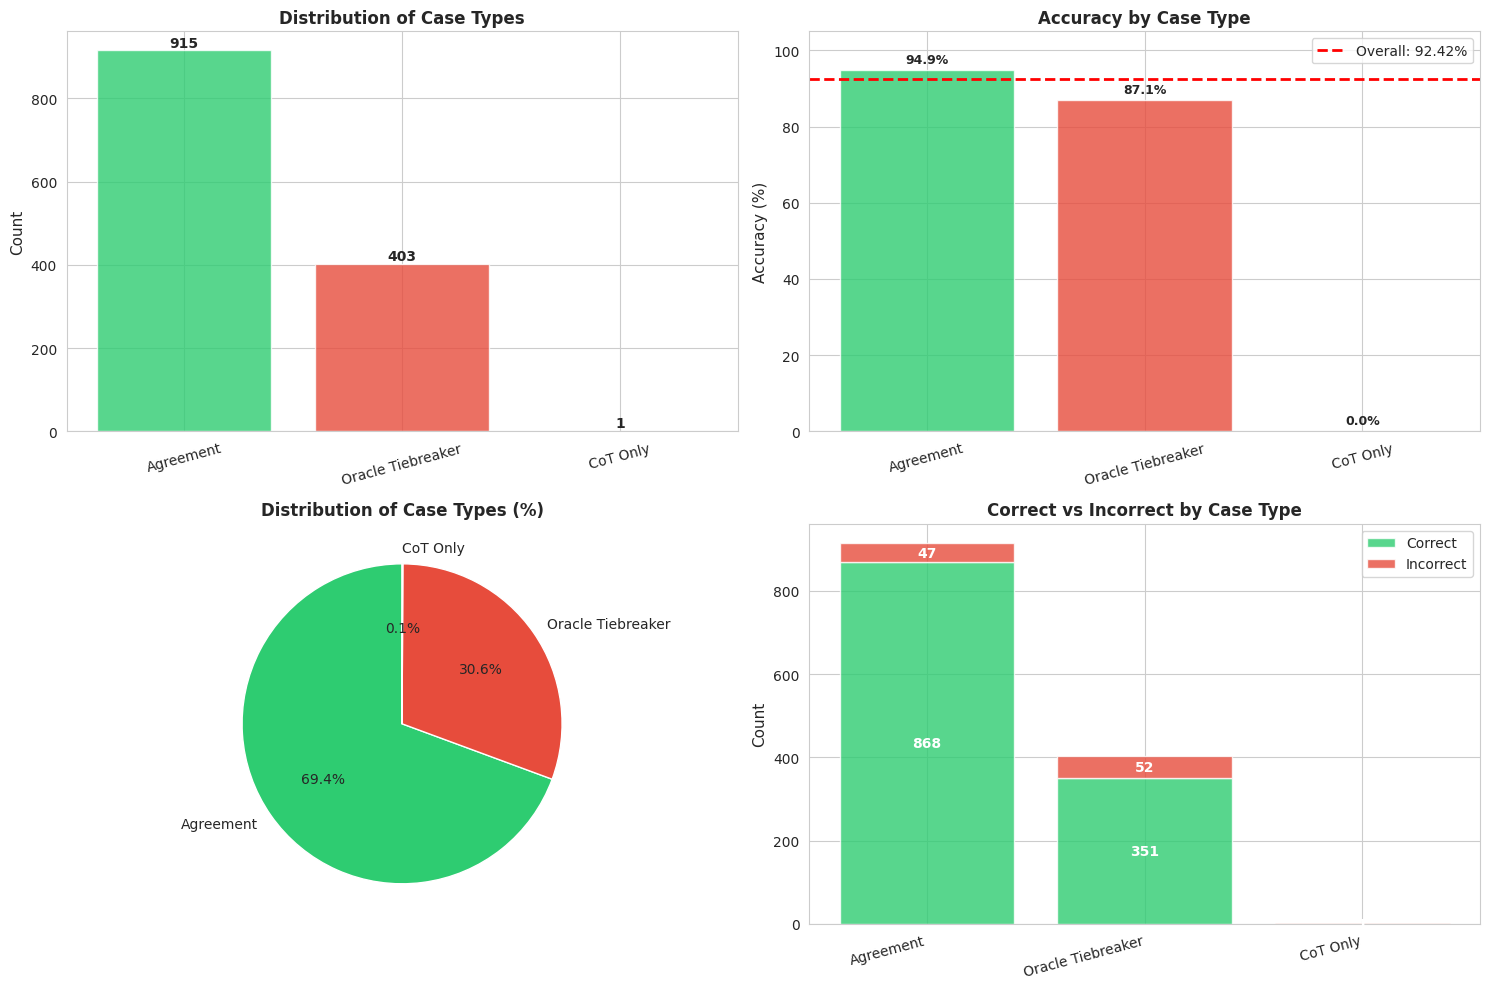

✓ Detailed case analysis visualizations created


In [11]:
# Figure 5: Detailed case analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prepare data for all cases
all_cases = {
    'Agreement': agreement_cases,
    'Oracle Tiebreaker': oracle_tiebreaker,
    'CoT Only': cot_only,
    'PoT Only': pot_only,
    'Oracle Fallback': oracle_fallback
}

# Remove empty cases
all_cases = {k: v for k, v in all_cases.items() if len(v) > 0}

# Chart 1: Count of each case type
case_names = list(all_cases.keys())
case_counts = [len(all_cases[c]) for c in case_names]
colors_cases = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6'][:len(case_names)]

axes[0, 0].bar(case_names, case_counts, color=colors_cases, alpha=0.8)
axes[0, 0].set_ylabel('Count', fontsize=11)
axes[0, 0].set_title('Distribution of Case Types', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)
for i, (name, count) in enumerate(zip(case_names, case_counts)):
    axes[0, 0].text(i, count + 1, str(count), ha='center', va='bottom', fontweight='bold')

# Chart 2: Accuracy for each case type
case_accuracies = [100 * all_cases[c]['correct'].sum() / len(all_cases[c]) for c in case_names]
bars = axes[0, 1].bar(case_names, case_accuracies, color=colors_cases, alpha=0.8)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=11)
axes[0, 1].set_title('Accuracy by Case Type', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim(0, 105)
axes[0, 1].axhline(y=overall_accuracy, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_accuracy:.2f}%')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].legend()
for i, (bar, acc) in enumerate(zip(bars, case_accuracies)):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., acc + 1, f'{acc:.1f}%',
                    ha='center', va='bottom', fontweight='bold', fontsize=9)

# Chart 3: Pie chart of case distribution
axes[1, 0].pie(case_counts, labels=case_names, autopct='%1.1f%%',
              colors=colors_cases, startangle=90)
axes[1, 0].set_title('Distribution of Case Types (%)', fontsize=12, fontweight='bold')

# Chart 4: Success count for each case
case_successes = [all_cases[c]['correct'].sum() for c in case_names]
case_failures = [case_counts[i] - case_successes[i] for i in range(len(case_names))]

x_pos = np.arange(len(case_names))
axes[1, 1].bar(x_pos, case_successes, label='Correct', color='#2ecc71', alpha=0.8)
axes[1, 1].bar(x_pos, case_failures, bottom=case_successes, label='Incorrect', color='#e74c3c', alpha=0.8)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(case_names, rotation=15, ha='right')
axes[1, 1].set_ylabel('Count', fontsize=11)
axes[1, 1].set_title('Correct vs Incorrect by Case Type', fontsize=12, fontweight='bold')
axes[1, 1].legend()

# Add labels
for i, (succ, fail) in enumerate(zip(case_successes, case_failures)):
    if succ > 0:
        axes[1, 1].text(i, succ/2, str(succ), ha='center', va='center', fontweight='bold', color='white')
    if fail > 0:
        axes[1, 1].text(i, succ + fail/2, str(fail), ha='center', va='center', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

print("✓ Detailed case analysis visualizations created")

## Section 8: Export Results Summary

In [12]:
# Create detailed results summary dataframe
detailed_stats = {
    'Metric': [
        'Total Problems Evaluated',
        'Overall Accuracy',
        '─' * 30,
        'Oracle Calls',
        'Oracle Call Rate',
        'Oracle Success Rate',
        'Oracle Success Count',
        'Oracle Failure Count',
        '─' * 30,
        'Agreement Cases',
        'Agreement Accuracy',
        'Agreement Success Count',
        '─' * 30,
        'Oracle Tiebreaker Cases',
        'Oracle Tiebreaker Accuracy',
        '─' * 30,
        'CoT-Only Cases',
        'CoT-Only Accuracy',
        '─' * 30,
        'PoT-Only Cases',
        'PoT-Only Accuracy',
        '─' * 30,
        'Oracle Fallback Cases',
        'Oracle Fallback Accuracy',
        '─' * 30,
        'Oracle Fixed Both Methods',
        'Oracle Called but Method Correct'
    ],
    'Value': [
        f"{total_problems}",
        f"{overall_accuracy:.2f}%",
        '',
        f"{oracle_called_count}",
        f"{oracle_called_percentage:.2f}%",
        f"{oracle_called_correct_percentage:.2f}%",
        f"{oracle_called_and_correct}",
        f"{oracle_called_and_incorrect}",
        '',
        f"{len(agreement_cases)}",
        f"{100 * agreement_cases['correct'].sum() / len(agreement_cases) if len(agreement_cases) > 0 else 0:.2f}%",
        f"{agreement_cases['correct'].sum()}",
        '',
        f"{len(oracle_tiebreaker)}",
        f"{100 * oracle_tiebreaker['correct'].sum() / len(oracle_tiebreaker) if len(oracle_tiebreaker) > 0 else 0:.2f}%",
        '',
        f"{len(cot_only)}",
        f"{100 * cot_only['correct'].sum() / len(cot_only) if len(cot_only) > 0 else 0:.2f}%",
        '',
        f"{len(pot_only)}",
        f"{100 * pot_only['correct'].sum() / len(pot_only) if len(pot_only) > 0 else 0:.2f}%",
        '',
        f"{len(oracle_fallback)}",
        f"{100 * oracle_fallback['correct'].sum() / len(oracle_fallback) if len(oracle_fallback) > 0 else 0:.2f}%",
        '',
        f"{oracle_fixed_both_wrong}",
        f"{oracle_called_method_correct}"
    ]
}

detailed_stats_df = pd.DataFrame(detailed_stats)

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(detailed_stats_df.to_string(index=False))
print("="*80)


FINAL RESULTS SUMMARY
                          Metric  Value
        Total Problems Evaluated   1319
                Overall Accuracy 92.42%
  ──────────────────────────────       
                    Oracle Calls    403
                Oracle Call Rate 30.55%
             Oracle Success Rate 87.10%
            Oracle Success Count    351
            Oracle Failure Count     52
  ──────────────────────────────       
                 Agreement Cases    915
              Agreement Accuracy 94.86%
         Agreement Success Count    868
  ──────────────────────────────       
         Oracle Tiebreaker Cases    403
      Oracle Tiebreaker Accuracy 87.10%
  ──────────────────────────────       
                  CoT-Only Cases      1
               CoT-Only Accuracy  0.00%
  ──────────────────────────────       
                  PoT-Only Cases      0
               PoT-Only Accuracy  0.00%
  ──────────────────────────────       
           Oracle Fallback Cases      0
        Oracle Fa

In [13]:
# Export to CSV (optional)
# Save the results to CSV files
results_csv_path = 'pipeline_analysis_results.csv'
detailed_stats_df.to_csv(results_csv_path, index=False)
print(f"\n✓ Detailed statistics exported to: {results_csv_path}")

# Create a summary for each case type
case_summary_data = []
for case_name, case_df in all_cases.items():
    case_summary_data.append({
        'Case Type': case_name,
        'Count': len(case_df),
        'Correct': case_df['correct'].sum(),
        'Accuracy %': f"{100 * case_df['correct'].sum() / len(case_df):.2f}%",
        'Oracle Used': case_df['oracle_called'].sum()
    })

case_summary_df = pd.DataFrame(case_summary_data)
case_csv_path = 'case_summary.csv'
case_summary_df.to_csv(case_csv_path, index=False)
print(f"✓ Case summary exported to: {case_csv_path}")

# Display final summary table
print("\n" + "="*80)
print("CASE SUMMARY TABLE")
print("="*80)
print(case_summary_df.to_string(index=False))
print("="*80)

print("\n✅ Analysis Complete! All statistics and visualizations have been generated.")


✓ Detailed statistics exported to: pipeline_analysis_results.csv
✓ Case summary exported to: case_summary.csv

CASE SUMMARY TABLE
        Case Type  Count  Correct Accuracy %  Oracle Used
        Agreement    915      868     94.86%            0
Oracle Tiebreaker    403      351     87.10%          403
         CoT Only      1        0      0.00%            0

✅ Analysis Complete! All statistics and visualizations have been generated.


In [14]:
# Section: Cases where final answer is wrong but one of CoT/PoT was correct
wrong_but_predictor_correct = []
for idx, row in df.iterrows():
    # final 'correct' indicates whether pipeline final_answer matched ground_truth
    if not row.get('correct', False):
        cot_correct = (row.get('cot_answer') is not None and row.get('cot_answer') == row.get('ground_truth'))
        pot_correct = (row.get('pot_answer') is not None and row.get('pot_answer') == row.get('ground_truth'))
        if cot_correct or pot_correct:
            wrong_but_predictor_correct.append({
                'index': idx,
                'question': row.get('question'),
                'final_answer': row.get('final_answer'),
                'ground_truth': row.get('ground_truth'),
                'cot_answer': row.get('cot_answer'),
                'pot_answer': row.get('pot_answer'),
                'cot_correct': cot_correct,
                'pot_correct': pot_correct,
                'method': row.get('method')
            })

print('Cases where final answer was wrong but one of the predictors was correct:', len(wrong_but_predictor_correct))

# Show table (up to first 200 cases)
if wrong_but_predictor_correct:
    wbpc_df = pd.DataFrame(wrong_but_predictor_correct)
    display(wbpc_df[['index','question','final_answer','ground_truth','cot_answer','pot_answer','cot_correct','pot_correct','method']].head(200))
    wbpc_df.to_csv('cases_final_wrong_but_predictor_correct.csv', index=False)
    print("Saved first 200 (or fewer) cases to cases_final_wrong_but_predictor_correct.csv")
else:
    print('None')

Cases where final answer was wrong but one of the predictors was correct: 15


,index,question,final_answer,ground_truth,cot_answer,pot_answer,cot_correct,pot_correct,method
0,43,John plans to sell all his toys and use the mo...,0.0000,2.0,3.00,2.0,False,True,oracle_tiebreaker
1,92,Christina is planning a birthday party and nee...,18.0000,24.0,18.00,24.0,False,True,oracle_tiebreaker
2,152,Debra is monitoring a beehive to see how many ...,90.0000,75.0,30.00,75.0,False,True,oracle_tiebreaker
3,202,Mandy owes Benedict $100. They agreed to have ...,2.0808,106.0,106.12,106.0,False,True,oracle_tiebreaker
4,587,90 single use contacts come in 1 box and will ...,1.0000,2.0,2.00,180.0,True,False,oracle_tiebreaker
5,782,Ava and Emma want to know who is better at the...,215.0000,25.0,5.00,25.0,False,True,oracle_tiebreaker
6,947,"The book is printed on paper that, when stacke...",150.0000,300.0,3.00,300.0,False,True,oracle_tiebreaker
7,1006,Jordan wanted to surprise her mom with a homem...,180.0000,2.0,2.00,-163.0,True,False,oracle_tiebreaker
8,1021,"On a busy Saturday morning, a hotel was comple...",113.0000,98.0,105.00,98.0,False,True,oracle_tiebreaker
9,1105,Ellen decided to play a prank on her friend. S...,20.0000,25.0,11.11,25.0,False,True,oracle_tiebreaker


Saved first 200 (or fewer) cases to cases_final_wrong_but_predictor_correct.csv
